In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit



def numeric_suffix_key(filename):
    stem = os.path.splitext(filename)[0]
    suffix = stem.rsplit("_", 1)[-1]
    return int(suffix) if suffix.isdigit() else float("inf")

def cauchy_offset(x, A, gamma, k):
        return A/(np.pi*gamma*(1 + ((x)/gamma)**2)) + k

def linfunc(x, a, b):
    return a*x + b

data_dir = "../output/Fourier/FirkantSingleFlip" # HUSK AT ÆNDRE DEN HER TIL DEN RIGTIGE MAPPE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

parameterFiles = np.array(sorted(os.listdir(data_dir + "/parameters"), key=numeric_suffix_key))
measurementFiles = np.array(sorted(os.listdir(data_dir + "/measurements"), key=numeric_suffix_key))
kvadratFFTFiles = np.array(sorted(os.listdir(data_dir + "/kvadratFFT"), key=numeric_suffix_key))
kvadratFFTVarFiles = np.array(sorted(os.listdir(data_dir + "/kvadratFFTvariance"), key=numeric_suffix_key))

print("Parameterfiler:", parameterFiles)
print("Måledatafiler:", measurementFiles)
print("Kvadrat FFT filer:", kvadratFFTFiles)
print("Kvadrat FFT varians filer:", kvadratFFTVarFiles)

størrelser = np.array([int(os.path.splitext(f)[0].split("_")[-1]) for f in parameterFiles])
parameter_data = np.genfromtxt(data_dir + "/parameters/" + parameterFiles[0], delimiter=",", skip_header=0)[:, :-1]
temperaturer = parameter_data[:, 1]

print("Størrelser:", størrelser)
print("Temperaturer:", temperaturer)

antalStørrelser = len(størrelser)
antalTemperaturer = len(temperaturer)


korrLen2D =np.zeros((antalStørrelser, antalTemperaturer))
korrLenUsik2D = np.zeros((antalStørrelser, antalTemperaturer))

magnetiseringer2D = np.zeros((antalStørrelser, antalTemperaturer))
magnetiseringerUsik2D = np.zeros((antalStørrelser, antalTemperaturer))

susceptibiliteter2D = np.zeros((antalStørrelser, antalTemperaturer))
susceptibiliteterUsik2D = np.zeros((antalStørrelser, antalTemperaturer))

energier2D = np.zeros((antalStørrelser, antalTemperaturer))
energierUsik2D = np.zeros((antalStørrelser, antalTemperaturer))

varmekapaciteter2D = np.zeros((antalStørrelser, antalTemperaturer))
varmekapaciteterUsik2D = np.zeros((antalStørrelser, antalTemperaturer))

print(antalTemperaturer)

# loop over hver enkelt simulation
for j in range(0,antalStørrelser):
    for i in range(0, antalTemperaturer):
        print(f"Processing size {størrelser[j]}, temperature {temperaturer[i]}...")

        parameters = np.genfromtxt(data_dir + "/parameters/" + parameterFiles[j], delimiter=",")[i,:-1]
        measurements = np.genfromtxt(data_dir + "/measurements/" + measurementFiles[j], delimiter=",")[i,:-1]
        kvadratFFT = np.genfromtxt(data_dir + "/kvadratFFT/" + kvadratFFTFiles[j], delimiter=",")[i,:-1]
        kvadratFFTVar = np.genfromtxt(data_dir + "/kvadratFFTvariance/" + kvadratFFTVarFiles[j], delimiter=",")[i,:-1]

        count = measurements[0]

        magnetiseringer2D[j, i] = measurements[1]
        magnetiseringerUsik2D[j, i] = np.sqrt(measurements[2] / count)  # Usikkerhed på magnetiseringen

        susceptibiliteter2D[j, i] = measurements[2]
        susceptibiliteterUsik2D[j, i] = np.sqrt(measurements[3] / count)  # Usikkerhed på susceptibiliteten

        energier2D[j, i] = measurements[4]
        energierUsik2D[j, i] = np.sqrt(measurements[5] / count)  # Usikkerhed på energien

        varmekapaciteter2D[j, i] = measurements[5]
        varmekapaciteterUsik2D[j, i] = np.sqrt(measurements[6] / count)  # Usikkerhed på varmekapaciteten



        # FFT shit
        kvadratFFT2D = np.fft.fftshift(np.split(kvadratFFT, størrelser[j]))
        kvadratFFT1D = kvadratFFT2D[int(størrelser[j]//2)]  # Tag den midterste række (k_y = 0)

        
        kvadratFFTVar2D = np.fft.fftshift(np.split(kvadratFFTVar, størrelser[j]))
        kvadratFFTVar1D = kvadratFFTVar2D[int(størrelser[j]//2)]  # Tag den midterste række (k_y = 0)


        kvadratFFT1Dusikkerhed = np.sqrt(kvadratFFTVar1D / count)  # Usikkerhed på gennemsnittet er standardafvigelsen delt med kvadratroden af antallet af målinger


        kvadratFFT1D = np.delete(kvadratFFT1D, størrelser[j]//2)  # Fjern det midterste element (k_y = 0)
        kvadratFFT1Dusikkerhed = np.delete(kvadratFFT1Dusikkerhed, størrelser[j]//2)  # Fjern usikkerheden for det midterste

        X = np.arange(-størrelser[j]//2, størrelser[j]//2)
        
        if (størrelser[j] % 2 == 1):
             X+=1
        
        X = X * 2 * np.pi / størrelser[j]  # Konverter til bølgetal
        X = np.delete(X, størrelser[j]//2)  # Fjern det midterste element (k_y = 0)



        p0 = [max(kvadratFFT1D), 0.1, min(kvadratFFT1D)]  # Initiale gæt for A, gamma og k
        par, cov = curve_fit(cauchy_offset, X, kvadratFFT1D, sigma=kvadratFFT1Dusikkerhed, p0=p0, maxfev=50000, bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]))

        korrlen = 1 / par[1]  # Korrrelationslængde er inversen af gamma
        korrlen_usikkerhed = cov[1, 1]**0.5 / par[1]**2  # Usikkerhed på korrrelationslængden
        korrLen2D[j, i] = korrlen
        korrLenUsik2D[j, i] = korrlen_usikkerhed

        '''
        plt.errorbar(X, kvadratFFT1D, yerr=kvadratFFT1Dusikkerhed, fmt='o', label='Data')
        x_fit = np.linspace(X.min(), X.max(), 1000)
        y_fit = cauchy_offset(x_fit, *par)
        plt.plot(x_fit, y_fit, label='Fit', color='red')
        plt.xlabel('Bølgetal k')
        plt.ylabel('Kvadrat af Fourier-transformationen')
        plt.title(f'Kvadrat FFT for størrelse {størrelser[j]} ved temperatur {temperaturer[i]}')
        plt.legend()
        plt.show()
        '''

for i in range(antalStørrelser):
    varmekapaciteter2D[i] *= størrelser[i]**2 / temperaturer**2

for i in range(antalStørrelser):
    for ii in range(antalTemperaturer):
        varmekapaciteter2D[i, ii] *= størrelser[i]**2 / temperaturer[ii]**2
        varmekapaciteterUsik2D[i, ii] *= størrelser[i]**2 / temperaturer[ii]**2
        susceptibiliteter2D[i, ii] *= størrelser[i]**2
        susceptibiliteterUsik2D[i, ii] *= størrelser[i]**2

Parameterfiler: ['parameters_24.csv' 'parameters_26.csv' 'parameters_28.csv'
 'parameters_30.csv' 'parameters_32.csv' 'parameters_34.csv'
 'parameters_36.csv' 'parameters_38.csv' 'parameters_42.csv'
 'parameters_44.csv' 'parameters_46.csv' 'parameters_50.csv'
 'parameters_52.csv' 'parameters_56.csv' 'parameters_58.csv'
 'parameters_62.csv' 'parameters_66.csv' 'parameters_72.csv'
 'parameters_78.csv' 'parameters_84.csv' 'parameters_90.csv'
 'parameters_100.csv' 'parameters_105.csv' 'parameters_110.csv'
 'parameters_118.csv' 'parameters_125.csv' 'parameters_134.csv'
 'parameters_142.csv' 'parameters_154.csv' 'parameters_166.csv'
 'parameters_180.csv' 'parameters_200.csv']
Måledatafiler: ['measurements_24.csv' 'measurements_26.csv' 'measurements_28.csv'
 'measurements_30.csv' 'measurements_32.csv' 'measurements_34.csv'
 'measurements_36.csv' 'measurements_38.csv' 'measurements_42.csv'
 'measurements_44.csv' 'measurements_46.csv' 'measurements_50.csv'
 'measurements_52.csv' 'measurements_5

C:\Users\Storm\AppData\Local\Temp\ipykernel_9620\2056867569.py:77: RuntimeWarning: invalid value encountered in sqrt
  susceptibiliteterUsik2D[j, i] = np.sqrt(measurements[3] / count)  # Usikkerhed på susceptibiliteten


Processing size 100, temperature 1.5...
Processing size 100, temperature 1.75...
Processing size 100, temperature 2.0...
Processing size 100, temperature 2.1...
Processing size 100, temperature 2.11...
Processing size 100, temperature 2.12...
Processing size 100, temperature 2.13...
Processing size 100, temperature 2.14...
Processing size 100, temperature 2.15...
Processing size 100, temperature 2.16...
Processing size 100, temperature 2.17...
Processing size 100, temperature 2.18...
Processing size 100, temperature 2.19...
Processing size 100, temperature 2.2...
Processing size 100, temperature 2.21...
Processing size 100, temperature 2.22...
Processing size 100, temperature 2.23...
Processing size 100, temperature 2.24...
Processing size 100, temperature 2.25...
Processing size 100, temperature 2.26...
Processing size 100, temperature 2.27...
Processing size 100, temperature 2.28...
Processing size 100, temperature 2.29...
Processing size 100, temperature 2.3...
Processing size 100, 

C:\Users\Storm\AppData\Local\Temp\ipykernel_9620\2056867569.py:83: RuntimeWarning: invalid value encountered in sqrt
  varmekapaciteterUsik2D[j, i] = np.sqrt(measurements[6] / count)  # Usikkerhed på varmekapaciteten


Processing size 118, temperature 1.5...
Processing size 118, temperature 1.75...
Processing size 118, temperature 2.0...
Processing size 118, temperature 2.1...
Processing size 118, temperature 2.11...
Processing size 118, temperature 2.12...
Processing size 118, temperature 2.13...
Processing size 118, temperature 2.14...
Processing size 118, temperature 2.15...
Processing size 118, temperature 2.16...
Processing size 118, temperature 2.17...
Processing size 118, temperature 2.18...
Processing size 118, temperature 2.19...
Processing size 118, temperature 2.2...
Processing size 118, temperature 2.21...
Processing size 118, temperature 2.22...
Processing size 118, temperature 2.23...
Processing size 118, temperature 2.24...
Processing size 118, temperature 2.25...
Processing size 118, temperature 2.26...
Processing size 118, temperature 2.27...
Processing size 118, temperature 2.28...
Processing size 118, temperature 2.29...
Processing size 118, temperature 2.3...
Processing size 118, 

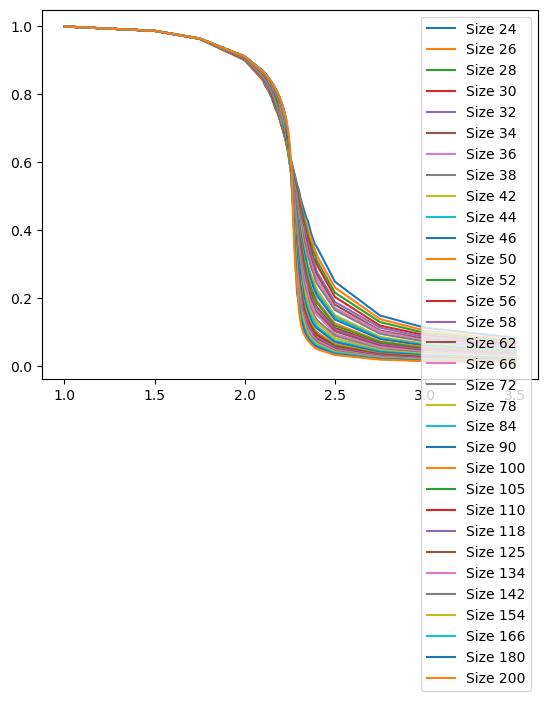

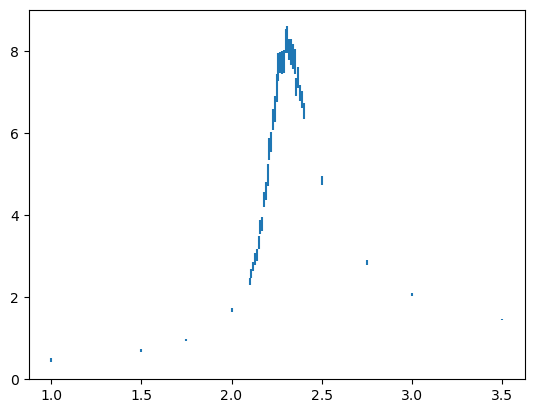

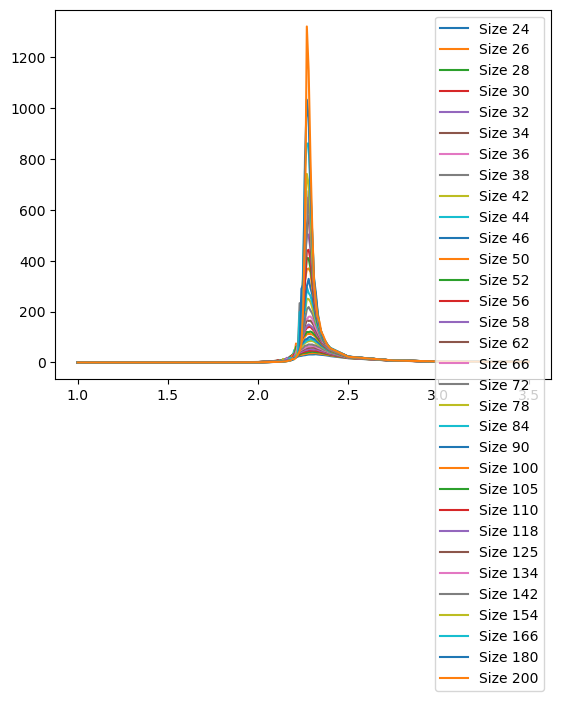

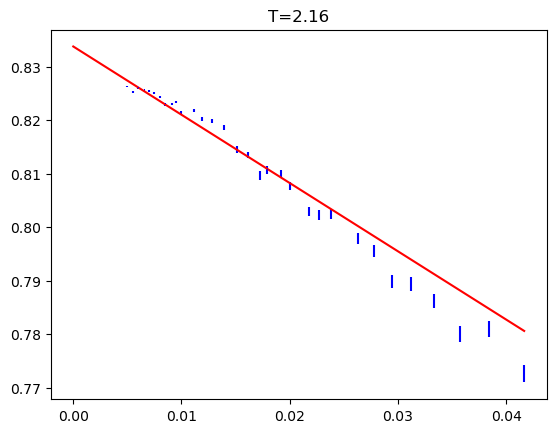

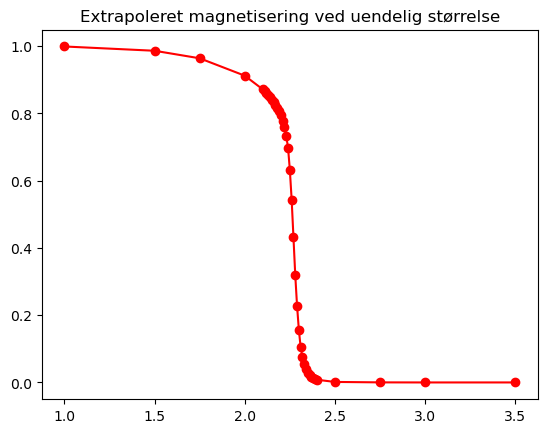

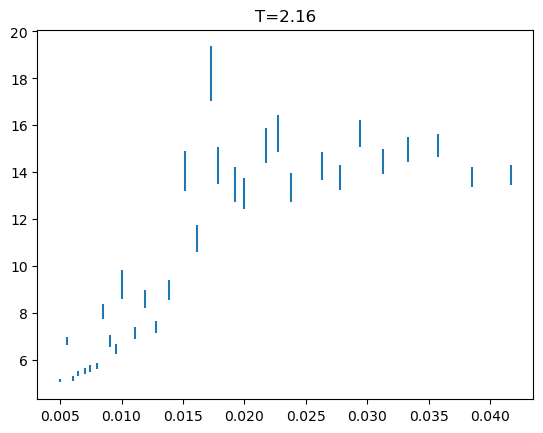

Kritisk temperatur fra parabolisk fit: 1.82876 ± 0.01906
Reduced chi-squared for parabolic fit: 37240.19


C:\Users\Storm\AppData\Local\Temp\ipykernel_9620\283117332.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  par, cov = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff]**1, susceptibiliteter2D[:, i][størrelser > sizeCutoff], sigma=susceptibiliteterUsik2D[:, i][størrelser > sizeCutoff], absolute_sigma=True)


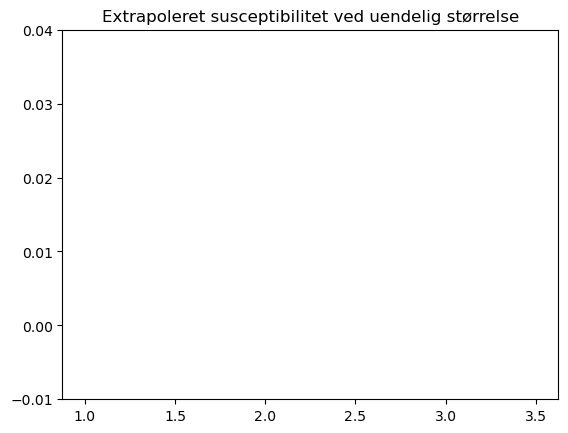

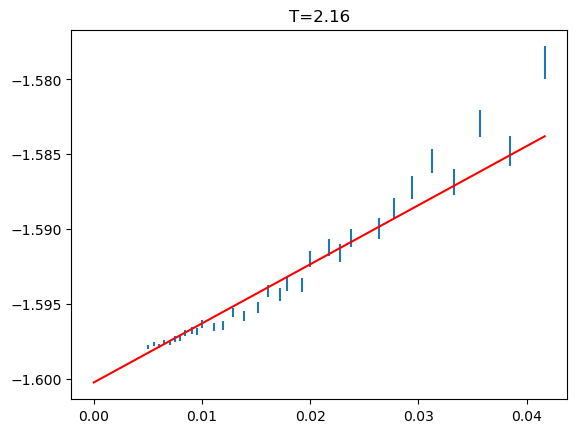

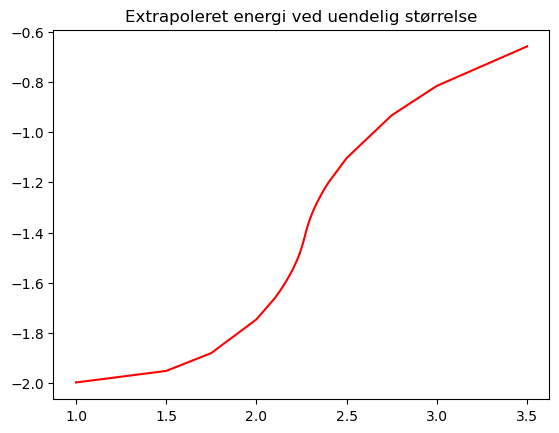

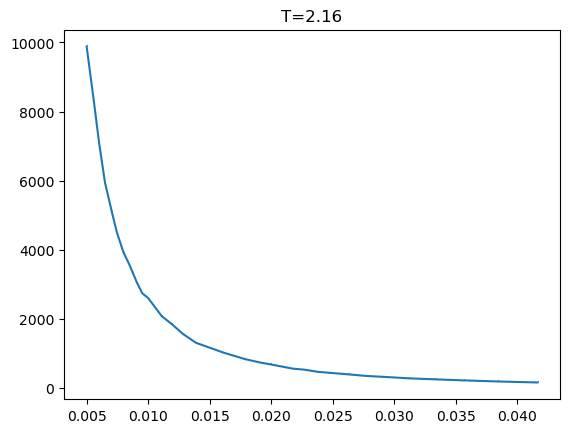

C:\Users\Storm\AppData\Local\Temp\ipykernel_9620\283117332.py:144: OptimizeWarning: Covariance of the parameters could not be estimated
  par, cov = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff]**1, varmekapaciteter2D[:, i][størrelser > sizeCutoff], sigma=varmekapaciteterUsik2D[:, i][størrelser > sizeCutoff]*1, absolute_sigma=True)


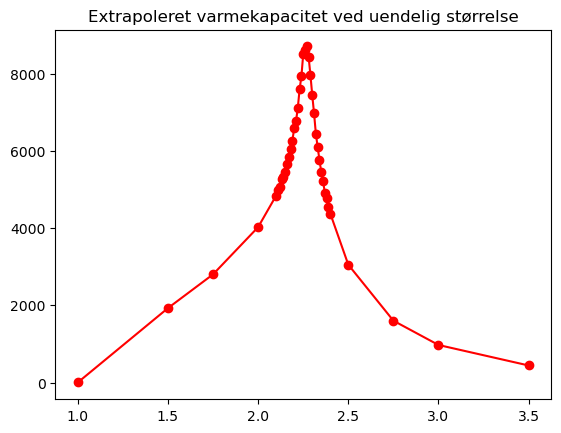

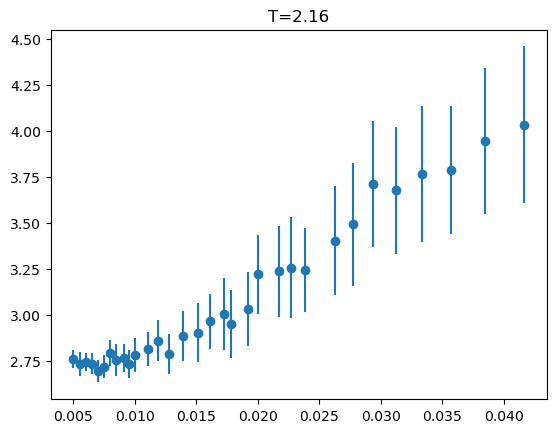

Extrapoleret kritisk temperatur: 2.3


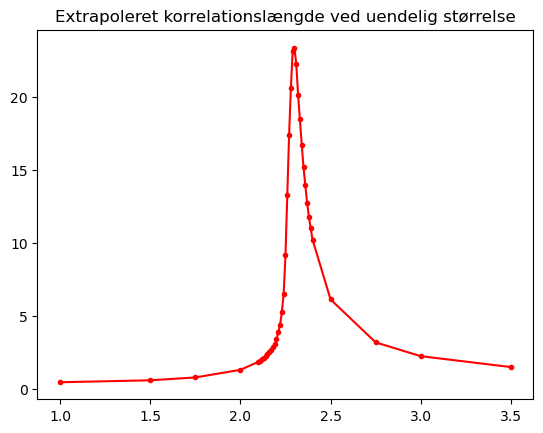

In [2]:

temptemp = 10
sizeCutoff = 0

for i in range(antalStørrelser):
    plt.plot(temperaturer, magnetiseringer2D[i], label=f"Size {størrelser[i]}")
    #plt.errorbar(temperaturer, magnetiseringer2D[i], yerr=magnetiseringerUsik2D[i], fmt='.', label=f"Data Size {størrelser[i]}")

plt.legend()
plt.show()

plt.errorbar(temperaturer, korrLen2D[5], yerr=korrLenUsik2D[5], fmt=',', label=f"Data Size {størrelser[0]}")
plt.show()

for i in range(antalStørrelser):
    plt.plot(temperaturer, susceptibiliteter2D[i], label=f"Size {størrelser[i]}")
plt.legend()
plt.show()






# 1/size magnetisering extrapolation
plt.errorbar(1/størrelser, magnetiseringer2D[:, temptemp], yerr=magnetiseringerUsik2D[:, temptemp], fmt=',', label='Data', color='blue')
partemp, covtemp = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff], magnetiseringer2D[:, temptemp][størrelser > sizeCutoff], sigma=magnetiseringerUsik2D[:, temptemp][størrelser > sizeCutoff]*4.5, absolute_sigma=True)
x_fit_temp = np.linspace(0, 1/størrelser.min(), 100)
y_fit_temp = linfunc(x_fit_temp, *partemp)
plt.plot(x_fit_temp, y_fit_temp, label='Lineær fit', color='red')
plt.title(f'T={temperaturer[temptemp]}')
plt.show()


extrapoleretMagnetisering = np.zeros(antalTemperaturer)
extrapoleretMagnetiseringUsik = np.zeros(antalTemperaturer)

#fit af lineær funktion
for i in range(antalTemperaturer):
    par, cov = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff], magnetiseringer2D[:, i][størrelser > sizeCutoff], sigma = magnetiseringerUsik2D[:, i][størrelser > sizeCutoff], absolute_sigma=True)
    x_fit = np.linspace(0, 1/størrelser.min(), 100)
    y_fit = linfunc(x_fit, *par)

    extrapoleretMagnetisering[i] = par[1]
    extrapoleretMagnetiseringUsik[i] = cov[1, 1]**0.5

#OBS:: overvurderede usikkerheder så x4.5mangel af korrelation:

plt.plot(temperaturer, extrapoleretMagnetisering, label='Lineær fit', color='red')
plt.errorbar(temperaturer, extrapoleretMagnetisering, yerr=extrapoleretMagnetiseringUsik, fmt='o', label='Extrapoleret data', color='red')
plt.title('Extrapoleret magnetisering ved uendelig størrelse')

plt.show()





plt.errorbar(1/(størrelser)**1, susceptibiliteter2D[:, temptemp], yerr=susceptibiliteterUsik2D[:, temptemp], fmt=',', label=f"Data Size {størrelser[0]}")
plt.title(f'T={temperaturer[temptemp]}')
plt.show()

extrapoleretSusceptibiliteter = np.zeros(antalTemperaturer)
extrapoleretSusceptibiliteterUsik = np.zeros(antalTemperaturer)
#fit af lineær funktion
for i in range(antalTemperaturer):
    par, cov = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff]**1, susceptibiliteter2D[:, i][størrelser > sizeCutoff], sigma=susceptibiliteterUsik2D[:, i][størrelser > sizeCutoff], absolute_sigma=True)
    x_fit = np.linspace(0, 1/størrelser.min(), 100)
    y_fit = linfunc(x_fit, *par)

    extrapoleretSusceptibiliteter[i] = par[1]
    extrapoleretSusceptibiliteterUsik[i] = cov[1, 1]**0.5


#plt.plot(temperaturer, extrapoleretSusceptibiliteter, label='Lineær fit', color='red')
plt.errorbar(temperaturer, extrapoleretSusceptibiliteter, yerr=extrapoleretSusceptibiliteterUsik, fmt='-', label='Extrapoleret data', color='red',)
plt.title('Extrapoleret susceptibilitet ved uendelig størrelse')
#plt.xlim(3,4)
#plt.xlim(2.2,2.4)
plt.ylim(-0.01, 0.04)

def parabola(x, x0, a, y0):
    return a*(x-x0)**2 + y0

par_sus, cov_sus = curve_fit(parabola, temperaturer, extrapoleretSusceptibiliteter, sigma=extrapoleretSusceptibiliteterUsik, p0=[2.3, 1, 0], absolute_sigma=True)   

x_par = np.linspace(temperaturer.min(), temperaturer.max(), 100)
y_par = parabola(x_par, *par_sus)
plt.plot(x_par, y_par, label='Parabolisk fit', color='green')

print(f"Kritisk temperatur fra parabolisk fit: {par_sus[0]:.5f} ± {cov_sus[0, 0]**0.5:.5f}")

chi2_red = np.sum(((extrapoleretSusceptibiliteter - parabola(temperaturer, *par_sus)) / extrapoleretSusceptibiliteterUsik) ** 2) / (len(temperaturer) - len(par_sus))
print(f"Reduced chi-squared for parabolic fit: {chi2_red:.2f}")


plt.show()





plt.errorbar(1/størrelser, energier2D[:, temptemp], yerr=energierUsik2D[:, temptemp], fmt=',', label=f"Data Size {størrelser[0]}")
partemp, covtemp = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff], energier2D[:, temptemp][størrelser > sizeCutoff], sigma=energierUsik2D[:, temptemp][størrelser > sizeCutoff], absolute_sigma=True)
x_fit_temp = np.linspace(0, 1/størrelser.min(), 100)
y_fit_temp = linfunc(x_fit_temp, *partemp)
plt.plot(x_fit_temp, y_fit_temp, label='Lineær fit', color='red')


plt.title(f'T={temperaturer[temptemp]}')
plt.show()

extrapoleretEnergier = np.zeros(antalTemperaturer)
extrapoleretEnergierUsik = np.zeros(antalTemperaturer)

#fit af lineær funktion
for i in range(antalTemperaturer):
    par, cov = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff], energier2D[:, i][størrelser > sizeCutoff], sigma=energierUsik2D[:, i][størrelser > sizeCutoff], absolute_sigma=True)
    x_fit = np.linspace(0, 1/størrelser.min(), 100)
    y_fit = linfunc(x_fit, *par)

    extrapoleretEnergier[i] = par[1]
    extrapoleretEnergierUsik[i] = cov[1, 1]**0.5


plt.plot(temperaturer, extrapoleretEnergier, label='Lineær fit', color='red')
plt.errorbar(temperaturer, extrapoleretEnergier, yerr=extrapoleretEnergierUsik, fmt=',', label='Extrapoleret data', color='red')
plt.title('Extrapoleret energi ved uendelig størrelse')

plt.show()




plt.errorbar(1/(størrelser)**1, varmekapaciteter2D[:, temptemp], yerr=varmekapaciteterUsik2D[:, temptemp], fmt=',-', label=f"Data Size {størrelser[0]}")
plt.title(f'T={temperaturer[temptemp]}')
plt.show()

extrapoleretVarmekapaciteter = np.zeros(antalTemperaturer)
extrapoleretVarmekapaciteterUsik = np.zeros(antalTemperaturer)


#fit af lineær funktion
for i in range(antalTemperaturer):
    par, cov = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff]**1, varmekapaciteter2D[:, i][størrelser > sizeCutoff], sigma=varmekapaciteterUsik2D[:, i][størrelser > sizeCutoff]*1, absolute_sigma=True)
    x_fit = np.linspace(0, 1/størrelser.min(), 100)
    y_fit = linfunc(x_fit, *par)

    extrapoleretVarmekapaciteter[i] = par[1]
    extrapoleretVarmekapaciteterUsik[i] = cov[1, 1]**0.5

plt.plot(temperaturer, extrapoleretVarmekapaciteter, label='Lineær fit', color='red')
plt.errorbar(temperaturer, extrapoleretVarmekapaciteter, yerr=extrapoleretVarmekapaciteterUsik, fmt='o', label='Extrapoleret data', color='red')
plt.title('Extrapoleret varmekapacitet ved uendelig størrelse')
#plt.xlim(2.2,2.4)
#plt.xlim(3,4)
#plt.ylim(-2e-5, 1.8e-4)

plt.show()


plt.errorbar(1/(størrelser)**1, korrLen2D[:, temptemp], yerr=korrLenUsik2D[:, temptemp]*2, fmt='o', label=f"Data Size {størrelser[0]}")
plt.title(f'T={temperaturer[temptemp]}')
plt.show()

extrapoleretKorrlen = np.zeros(antalTemperaturer)
extrapoleretKorrlenUsik = np.zeros(antalTemperaturer)

#fit af lineær funktion
for i in range(antalTemperaturer):
    par, cov = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff]**1, korrLen2D[:, i][størrelser > sizeCutoff], sigma=korrLenUsik2D[:, i][størrelser > sizeCutoff], absolute_sigma=True)
    x_fit = np.linspace(0, 1/størrelser.min(), 100)
    y_fit = linfunc(x_fit, *par)

    extrapoleretKorrlen[i] = par[1]
    extrapoleretKorrlenUsik[i] = cov[1, 1]**0.5

Tc = temperaturer[np.argmax(extrapoleretKorrlen)]
print(f"Extrapoleret kritisk temperatur: {Tc}") 

plt.errorbar(temperaturer, extrapoleretKorrlen, yerr=extrapoleretKorrlenUsik, fmt='.-', label='Extrapoleret data', color='red')
plt.title('Extrapoleret korrelationslængde ved uendelig størrelse')

plt.show()


Temperaturer til fit: [2.21 2.22 2.23 2.24 2.25]


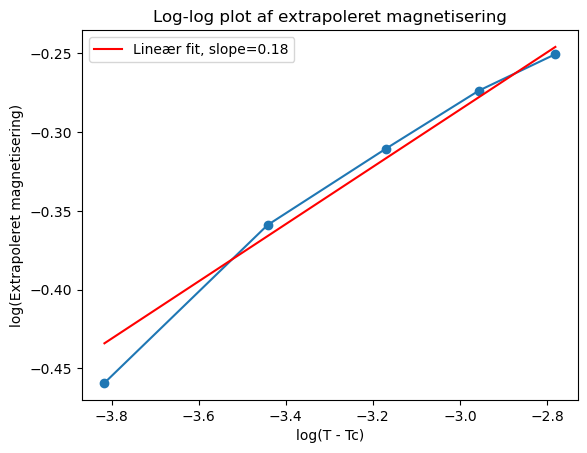

Kritisk eksponent for susceptibilitet: 0.182 ± 0.001


In [3]:
#find kritiske eksponenter ved at plotte log-log af magnetisering og temp

Tc = 2.272


startIndex = 15
endIndex = 20

print(f"Temperaturer til fit: {temperaturer[startIndex:endIndex]}")

plt.plot(np.log(Tc-temperaturer[startIndex:endIndex]), np.log(extrapoleretMagnetisering[startIndex:endIndex]), 'o-')
plt.xlabel('log(T - Tc)')
plt.ylabel('log(Extrapoleret magnetisering)')
plt.title('Log-log plot af extrapoleret magnetisering')

#fit af lineær funktion
par, cov = curve_fit(linfunc, np.log(Tc-temperaturer[startIndex:endIndex]), np.log(extrapoleretMagnetisering[startIndex:endIndex]), sigma=extrapoleretMagnetiseringUsik[startIndex:endIndex]/extrapoleretMagnetisering[startIndex:endIndex], absolute_sigma=True)
x_fit = np.linspace(np.log(Tc-temperaturer[startIndex]), np.log(Tc-temperaturer[endIndex-1]), 100)
y_fit = linfunc(x_fit, *par)
plt.plot(x_fit, y_fit, label=f'Lineær fit, slope={par[0]:.2f}', color='red')
plt.legend()
plt.show()

print(f"Kritisk eksponent for susceptibilitet: {par[0]:.3f} ± {cov[0, 0]**0.5:.3f}")

In [4]:
heatmap_dir = "../output/Fourier" # HUSK AT ÆNDRE DEN HER TIL DEN RIGTIGE MAPPE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
heatmapParameters = np.genfromtxt(heatmap_dir + "/parameters/parameters_64.csv", delimiter=",", skip_header=0)[:, :-1]
heatmapmeasurements = np.genfromtxt(heatmap_dir + "/measurements/measurements_64.csv", delimiter=",", skip_header=0)[:, :-1]

temperaturer = np.unique(heatmapParameters[:][1])
magnetfelter = np.unique(heatmapParameters[:][2])
magnetiseringer = np.zeros((len(temperaturer), len(magnetfelter)))
for i in range(len(temperaturer)):
    for j in range(len(magnetfelter)):
        magnetiseringer[i,j] = heatmapmeasurements[i*len(magnetfelter) + j, 1]


#lav et heatmap af magnetisering for alle magnetfelter og temperaturer

plt.figure(figsize=(16,16))
plt.imshow(magnetiseringer, extent=(magnetfelter.min(), magnetfelter.max(), temperaturer.min(), temperaturer.max()), aspect='auto', origin='lower', cmap=cm.viridis, norm=mcolors.Normalize(vmin=0, vmax=1))
plt.colorbar(label='Magnetisering')
plt.xlabel('Temperatur')
plt.ylabel('Størrelse')
plt.title('Magnetisering som funktion af temperatur og størrelse')
plt.show()

FileNotFoundError: ../output/Fourier/parameters/parameters_64.csv not found.

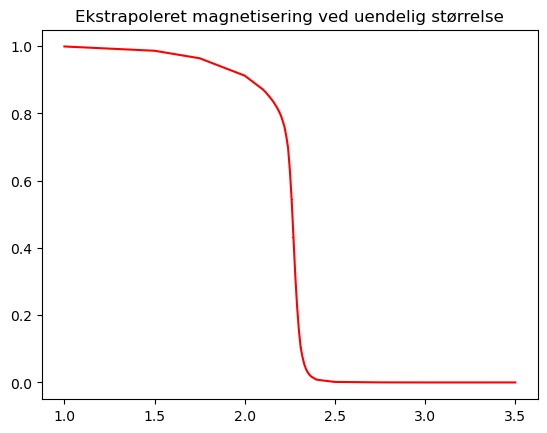

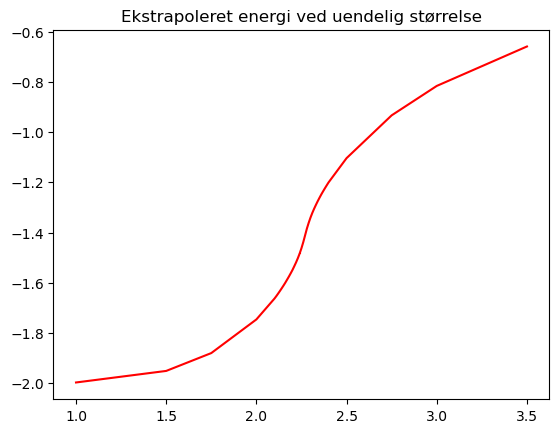

C:\Users\Storm\AppData\Local\Temp\ipykernel_9620\1654032945.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  par, cov = curve_fit(linfunc, 1/størrelser, susceptibiliteter2D[:,i], sigma=susceptibiliteterUsik2D[:,i], absolute_sigma=True)


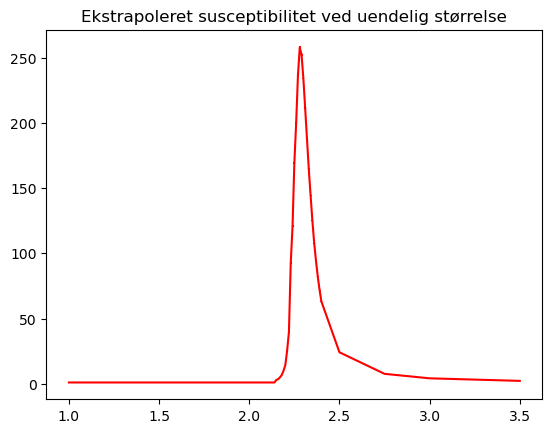

C:\Users\Storm\AppData\Local\Temp\ipykernel_9620\1654032945.py:42: OptimizeWarning: Covariance of the parameters could not be estimated
  par, cov = curve_fit(linfunc, 1/størrelser, varmekapaciteter2D[:,i], sigma=varmekapaciteterUsik2D[:,i], absolute_sigma=True)


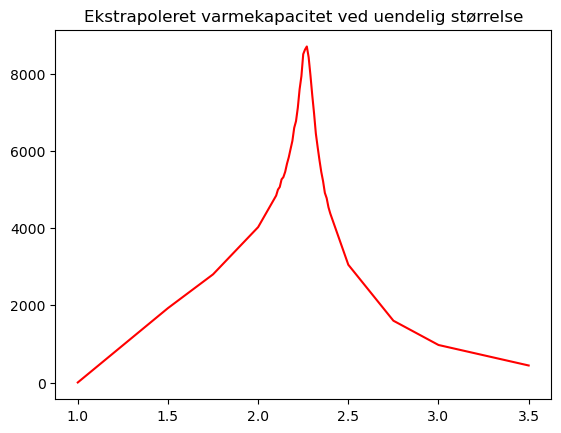

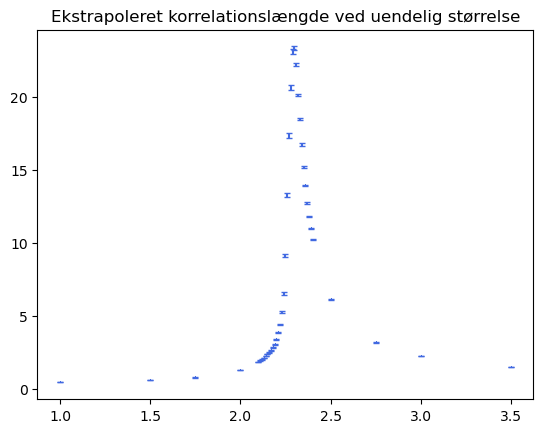

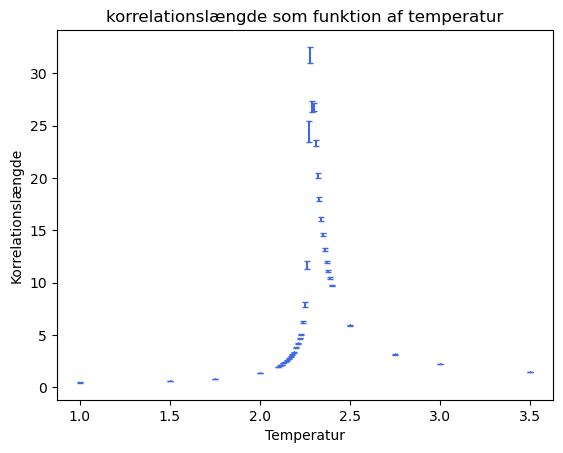

In [ ]:
ekstrapoleretMagnetisering = np.zeros(len(temperaturer))
ekstrapoleretMagnetiseringUsik = np.zeros(len(temperaturer))
for i in range(len(temperaturer)):
    par, cov = curve_fit(linfunc, 1/størrelser, magnetiseringer2D[:,i], sigma=magnetiseringerUsik2D[:,i], absolute_sigma=True)
    ekstrapoleretMagnetisering[i] = par[1]  # Tag den ekstrapolerede magnetisering (b)
    ekstrapoleretMagnetiseringUsik[i] = cov[1, 1]**0.5  # Usikkerhed på den ekstrapolerede magnetisering (b)


plt.errorbar(temperaturer, ekstrapoleretMagnetisering, yerr=ekstrapoleretMagnetiseringUsik, label='Ekstrapoleret magnetisering', color='red')
plt.title('Ekstrapoleret magnetisering ved uendelig størrelse')
plt.show()


ekstrapoleretEnergier = np.zeros(len(temperaturer))
ekstrapoleretEnergierUsik = np.zeros(len(temperaturer))
for i in range(len(temperaturer)):
    par, cov = curve_fit(linfunc, 1/størrelser, energier2D[:,i], sigma=energierUsik2D[:,i], absolute_sigma=True)
    ekstrapoleretEnergier[i] = par[1]  # Tag den ekstrapolerede energi (b)
    ekstrapoleretEnergierUsik[i] = cov[1, 1]**0.5  # Usikkerhed på den ekstrapolerede energi (b)


plt.errorbar(temperaturer, ekstrapoleretEnergier, yerr=ekstrapoleretEnergierUsik, fmt='-', label='Ekstrapoleret energi', color='red')
plt.title('Ekstrapoleret energi ved uendelig størrelse')
plt.show()


ekstrapoleretSusceptibiliteter = np.zeros(len(temperaturer))
ekstrapoleretSusceptibiliteterUsik = np.zeros(len(temperaturer))
for i in range(len(temperaturer)):
    par, cov = curve_fit(linfunc, 1/størrelser, susceptibiliteter2D[:,i], sigma=susceptibiliteterUsik2D[:,i], absolute_sigma=True)
    ekstrapoleretSusceptibiliteter[i] = par[1]  # Tag den ekstrapolerede susceptibilitet (b)
    ekstrapoleretSusceptibiliteterUsik[i] = cov[1, 1]**0.5  # Usikkerhed på den ekstrapolerede susceptibilitet (b)

plt.errorbar(temperaturer, ekstrapoleretSusceptibiliteter, yerr=ekstrapoleretSusceptibiliteterUsik, fmt='-', label='Ekstrapoleret susceptibilitet', color='red')
plt.title('Ekstrapoleret susceptibilitet ved uendelig størrelse')
plt.show()


ekstrapoleretVarmekapaciteter = np.zeros(len(temperaturer))
ekstrapoleretVarmekapaciteterUsik = np.zeros(len(temperaturer))
for i in range(len(temperaturer)):
    par, cov = curve_fit(linfunc, 1/størrelser, varmekapaciteter2D[:,i], sigma=varmekapaciteterUsik2D[:,i], absolute_sigma=True)
    ekstrapoleretVarmekapaciteter[i] = par[1]  # Tag den ekstrapolerede varmekapacitet (b)
    ekstrapoleretVarmekapaciteterUsik[i] = cov[1, 1]**0.5  # Usikkerhed på den ekstrapolerede varmekapacitet (b)

plt.errorbar(temperaturer, ekstrapoleretVarmekapaciteter, yerr=ekstrapoleretVarmekapaciteterUsik, fmt='-', label='Ekstrapoleret varmekapacitet', color='red')
plt.title('Ekstrapoleret varmekapacitet ved uendelig størrelse')
plt.show()


ekstrapoleretKorrlen = np.zeros(len(temperaturer))
ekstrapoleretKorrlenUsik = np.zeros(len(temperaturer))
for i in range(len(temperaturer)):
    par, cov = curve_fit(linfunc, 1/størrelser, korrLen2D[:,i], sigma=korrLenUsik2D[:,i], absolute_sigma=True)
    ekstrapoleretKorrlen[i] = par[1]  # Tag den ekstrapolerede korrelationslængde (b)
    ekstrapoleretKorrlenUsik[i] = cov[1, 1]**0.5  # Usikkerhed på den ekstrapolerede korrelationslængde (b)


plt.errorbar(temperaturer, ekstrapoleretKorrlen, yerr=ekstrapoleretKorrlenUsik, fmt=',', capsize=2, label='Ekstrapoleret korrelationslængde', color='royalblue')
plt.title('Ekstrapoleret korrelationslængde ved uendelig størrelse')
plt.show()

#for size 200 plot af korrelationslængde vs temperatur med errorbars
plt.errorbar(temperaturer, korrLen2D[-1], yerr=korrLenUsik2D[-1], fmt=',', capsize=2, label=f"Data Size {størrelser[-1]}", color='royalblue')
plt.title("korrelationslængde som funktion af temperatur")
plt.xlabel("Temperature (T)")
plt.ylabel(r"correlation length ($\xi$)")
plt.show()

 